In [20]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
from datetime import datetime, timedelta

In [21]:
# basic configuration settings used throughout the script
CONFIG = {
    'pools': ['ETH/USDC', 'BTC/USDC', 'LINK/USDC'],
    'fee_tier': 0.003,
    'tick_spacing': 60,
    'hours_total': 3000,
    'action_widths': [0,1,2,3,4,5],
    'base_tick_width': 200,
    'flat_gas_cost': 50.0,
    'ddqn': {
        'hidden_sizes': [128,128],
        'lr': 1e-4,
        'batch_size': 128,
        'buffer_size': 100_000,
        'gamma': 0.9,
        'target_tau': 0.01,
        'grad_clip': 0.7,
        'epsilon_start': 1.0,
        'epsilon_end': 0.05,
        'epsilon_decay_steps': 50_000,
    },

    'train_hours': 2400,
    'val_hours': 300,
    'test_hours': 300,

    'initial_capital_list': [250.0, 500.0, 1000.0],
    'seed': 67
}

np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
random.seed(CONFIG['seed'])
CONFIG['ret'] = 18 if 1000.0 in CONFIG['initial_capital_list'] else 1


# this function creates synthetic data (Geometric Brownian Motion) for multiple pools; it's basically generating made-up price series,
# liquidity, and volume so the RL model has something to train on
def load_multi_pool_data(pools, hours_total):
    result = {}
    start = datetime(2021, 8, 2)

    for i, pool in enumerate(pools):
        # rough starting values for price, drift, and volatility so each pool behaves differently
        S0 = 2000.0 * (1 + 0.2*(i-1))
        mu = 0.00012 + 0.00002*i
        sigma = 0.012 + 0.008*(i/max(1, len(pools)-1))

        prices = [S0]
        dt = 1.0

        # generating a simple GBM price series
        for _ in range(hours_total-1):
            dW = np.random.normal(0, np.sqrt(dt))
            dP = mu*prices[-1]*dt + sigma*prices[-1]*dW
            new_price = prices[-1] + dP
            new_price = max(0.1, min(20000.0, new_price))
            prices.append(new_price)

        prices = np.array(prices)

        # generating highs and lows by adding random noise
        high = prices*(1+np.abs(np.random.normal(0,0.003+0.001*i,hours_total)))
        low  = prices*(1-np.abs(np.random.normal(0,0.003+0.001*i,hours_total)))

        # open price is yesterday’s close, except first entry
        open_p = np.roll(prices,1); open_p[0] = prices[0]

        # synthetic volume based on price movement
        base_vol = 1_000_000*(1+i*0.5)
        price_change = np.abs(np.diff(prices, prepend=prices[0]))/prices
        vol_multiplier = 1 + price_change*(10+i*5)
        volume = base_vol * vol_multiplier * np.abs(np.random.normal(1,0.3,hours_total))
        volume = np.clip(volume, 10_000, 50_000_000)

        # converting prices to ticks using the logarithmic tick formula
        ticks = (np.log(prices)/np.log(1.0001)).astype(int)

        # random synthetic liquidity
        base_liq = 100_000_000*(1+0.2*i)
        liquidity = base_liq * np.abs(np.random.normal(1.0, 0.1 + 0.02*i, hours_total))
        liquidity = np.clip(liquidity, 10_000_000, 1_000_000_000)

        timestamps = [start + timedelta(hours=h) for h in range(hours_total)]

        df = pd.DataFrame({
            'timestamp': timestamps,
            'open': open_p,
            'high': high,
            'low': low,
            'close': prices,
            'volume_usd': volume,
            'liquidity': liquidity,
            'tick': ticks
        })

        result[i] = df

    return result


multi_pool_data = load_multi_pool_data(CONFIG['pools'], CONFIG['hours_total'])


In [22]:
# this function adds several simple feature columns that the RL model can use
def create_features_for_df(df):
    df = df.copy()
    price = df['close'].values
    volume = df['volume_usd'].values

    # simple log returns
    log_returns = np.diff(np.log(price), prepend=np.log(price[0]))

    # a few rolling averages and volatilities
    df['ret_1h'] = pd.Series(log_returns).rolling(1,min_periods=1).mean().fillna(0)
    df['ret_6h'] = pd.Series(log_returns).rolling(6,min_periods=1).mean().fillna(0)
    df['ret_24h'] = pd.Series(log_returns).rolling(24,min_periods=1).mean().fillna(0)
    df['vol_6h'] = pd.Series(log_returns).rolling(6,min_periods=1).std().fillna(0.001)
    df['vol_24h'] = pd.Series(log_returns).rolling(24,min_periods=1).std().fillna(0.001)

    # relative volume to its 24-hour moving average
    vol_ma = pd.Series(volume).rolling(24,min_periods=1).mean().fillna(volume.mean())
    df['vol_ratio'] = np.clip((volume/(vol_ma+1e-8))-1, -1, 1)

    # momentum based on rolling log returns
    df['price_momentum'] = pd.Series(log_returns).rolling(12,min_periods=1).sum().fillna(0)

    feature_cols = ['ret_1h','ret_6h','ret_24h',
                    'vol_6h','vol_24h','vol_ratio',
                    'price_momentum']

    # normalizing features so they’re not too large or too small
    for col in feature_cols:
        m = df[col].mean(); s = df[col].std()+1e-8
        df[col] = np.clip((df[col]-m)/s, -3,3)

    return df, feature_cols


pool_dfs = {}
FEATURE_COLS = None
for p, df in multi_pool_data.items():
    df_f, fcols = create_features_for_df(df)
    pool_dfs[p] = df_f.reset_index(drop=True)
    FEATURE_COLS = fcols


In [23]:
# this class simulates a Uniswap v3 position in a very simplified way:
# it tracks deposited amounts, fees collected, and approximate value (used for single pool calculation of baselines)
class UniswapV3Position:
    def __init__(self, fee_tier=0.003):
        self.fee_tier = fee_tier
        self.reset()

    # resets everything so the position behaves like brand new
    def reset(self):
        self.liquidity = 0.0
        self.tick_lower = None
        self.tick_upper = None
        self.price_lower = None
        self.price_upper = None
        self.token0_deposited = 0.0
        self.token1_deposited = 0.0
        self.fees_earned_0 = 0.0
        self.fees_earned_1 = 0.0
        self.is_active = False
        self.deploy_price = None
        self.steps_in_range = 0
        self.total_steps = 0

    # creates a new position with a chosen price range and capital
    def deploy(self, capital_usd, current_price, tick_lower, tick_upper):
        self.reset()
        capital_usd = np.clip(capital_usd, 0.0, 1e8)
        current_price = max(current_price, 1e-8)

        self.tick_lower = tick_lower
        self.tick_upper = tick_upper
        self.deploy_price = current_price
        self.is_active = True

        # converting ticks back to actual price boundaries
        self.price_lower = 1.0001**tick_lower
        self.price_upper = 1.0001**tick_upper

        # allocating capital between token0 and token1 depending on where current price sits
        if current_price <= self.price_lower:
            self.token0_deposited = capital_usd
            self.token1_deposited = 0.0
        elif current_price >= self.price_upper:
            self.token0_deposited = 0.0
            self.token1_deposited = capital_usd/current_price
        else:
            self.token0_deposited = capital_usd*0.5
            self.token1_deposited = (capital_usd*0.5)/current_price

        # rough liquidity formula (not an exact Uniswap V3 implementation)
        sqrt_p = np.sqrt(current_price)
        sqrt_pl = np.sqrt(self.price_lower)
        sqrt_pu = np.sqrt(self.price_upper)

        if self.token0_deposited>0 and self.token1_deposited>0:
            self.liquidity = np.sqrt(self.token0_deposited*self.token1_deposited*current_price)
        elif self.token0_deposited>0:
            self.liquidity = self.token0_deposited/sqrt_pl
        else:
            self.liquidity = self.token1_deposited*sqrt_pu

        self.liquidity = np.clip(self.liquidity, 0, 1e9)

    # collects a portion of fees whenever the price is inside the position range
    def collect_fees(self, current_price, volume_usd):
        if not self.is_active or self.liquidity<=0:
            return 0.0

        self.total_steps += 1

        in_range = (current_price>=self.price_lower and current_price<=self.price_upper)
        if not in_range:
            return 0.0

        self.steps_in_range += 1

        # this is a made-up formula giving a tiny share of pool fees
        liquidity_share = 0.01
        fees = volume_usd * self.fee_tier * liquidity_share
        fees = np.clip(fees, 0, volume_usd*0.1)

        # split fees between token0 and token1
        self.fees_earned_0 += fees*0.5
        self.fees_earned_1 += (fees*0.5)/current_price

        return float(fees)

    # returns the approximate USD value of everything in the position
    def get_position_value(self, current_price):
        if not self.is_active:
            return 0.0

        val0 = self.token0_deposited
        val1 = self.token1_deposited*current_price
        fee0 = self.fees_earned_0
        fee1 = self.fees_earned_1*current_price

        return float(val0 + val1 + fee0 + fee1)

    # estimates impermanent loss based on price movement from the deployment price
    def get_impermanent_loss(self, current_price):
        if not self.is_active or self.deploy_price is None:
            return 0.0

        original = self.token0_deposited + self.token1_deposited*self.deploy_price
        ratio = current_price/self.deploy_price

        if ratio != 1.0:
            il_ratio = 2*np.sqrt(ratio)/(1+ratio) - 1
            il = original * abs(il_ratio)
        else:
            il = 0.0

        return float(np.clip(il, 0, original*0.5))



    # keeps track of how often the price has remained inside the chosen range
    def get_in_range_ratio(self):
        if self.total_steps == 0:
            return 0.0
        return self.steps_in_range/self.total_steps
init_capital=[0,0,0]
kj = 0
for init_cap in CONFIG['initial_capital_list']:
    init_capital[kj] = 25000/((init_cap/750)+0.36)
    kj += 1

In [24]:
# Environment for handling multiple Uniswap-like pools at once.
# This environment is used in both the normal single-pool DRL and the multi-pool DRL-MP setup.

class UniswapMultiPoolEnv:
    def __init__(self, pool_dfs, features, config, initial_capital):
        # pool_dfs contains the synthetic data for each pool
        # features is the list of engineered state inputs
        # config holds hyperparameters
        # initial_capital is starting cash for the whole environment
        self.pool_names = list(pool_dfs.keys())
        self.pool_dfs = pool_dfs
        self.features = features
        self.config = config
        self.initial_capital = initial_capital

        self.n_pools = len(self.pool_names)

        # each pool contributes its feature set plus some position-related values
        self.per_pool_state_len = len(self.features) + 4
        self.n_features = self.n_pools * self.per_pool_state_len + 1

        # allowable width multipliers for rebalancing
        self.widths = config['action_widths']
        self.n_width_nonzero = max(0, len(self.widths)-1)

        # action 0 means "do nothing", and other actions correspond to picking a pool and a width
        self.n_actions = 1 + self.n_pools * self.n_width_nonzero

        # create an empty position object for each pool
        self.positions = {p: UniswapV3Position(config['fee_tier']) for p in self.pool_names}

        self.reset()


    # resets the environment to a fresh state
    def reset(self, start_idx=0):
        self.start_idx = start_idx
        self.step_idx = start_idx

        # split cash evenly at reset
        self.cash_per_pool = {p: self.initial_capital/self.n_pools for p in self.pool_names}
        self.positions = {p: UniswapV3Position(self.config['fee_tier']) for p in self.pool_names}

        self.episode_fees = 0.0
        self.episode_gas = 0.0
        self.episode_il  = 0.0
        self.n_rebalances = 0
        self.history = []

        return self._get_state()


    # constructs the current state vector for the agent
    def _get_state(self):
        df0 = self.pool_dfs[self.pool_names[0]]
        if self.step_idx >= len(df0):
            # if out of data, just return zeros
            return np.zeros(self.n_features, dtype=np.float32)

        pool_states = []
        total_cash = sum(self.cash_per_pool.values())

        # loop through each pool and pack its market features and position traits
        for p in self.pool_names:
            row = self.pool_dfs[p].loc[self.step_idx]

            # market indicators from feature engineering
            market_state = row[self.features].values.astype(np.float32)
            market_state = np.nan_to_num(market_state, 0.0)
            market_state = np.clip(market_state, -5, 5)

            # position-related values
            price = row['close']
            pos = self.positions[p]

            if pos.is_active and pos.tick_lower is not None:
                tick = int(np.log(price)/np.log(1.0001))
                in_range = 1.0 if (tick>=pos.tick_lower and tick<=pos.tick_upper) else 0.0
                width = (pos.tick_upper - pos.tick_lower)/1000.0

                pos_value = pos.get_position_value(price) + self.cash_per_pool[p]
                value_ratio = pos_value / (self.initial_capital/self.n_pools + 1e-8)
                in_range_ratio = pos.get_in_range_ratio()
            else:
                in_range = 0.0
                width = 0.0
                value_ratio = 1.0
                in_range_ratio = 0.0

            # pack them as small vector
            position_state = np.array([
                in_range,
                np.clip(width,0,5),
                np.clip(np.log(value_ratio+1e-8), -3,3),
                in_range_ratio
            ], dtype=np.float32)

            pool_states.append(np.concatenate([market_state, position_state]))

        total_cash_ratio = total_cash/(self.initial_capital+1e-8)
        flat = np.array([np.clip(total_cash_ratio, 0.0, 10.0)], dtype=np.float32)

        # final state is all pool states concatenated with total cash metric
        return np.concatenate(pool_states + [flat])


    # steps the environment forward by one time point
    def step(self, action):
        df0 = self.pool_dfs[self.pool_names[0]]

        # stop if we are out of data
        if self.step_idx >= len(df0)-1:
            return self._get_state(), 0.0, True, {}

        total_fees_this_step = 0.0
        reward_comp = {'fees':0.0, 'gas':0.0, 'il':0.0}

        # collect fees from every pool’s active position
        for p in self.pool_names:
            row = self.pool_dfs[p].loc[self.step_idx]
            price = row['close']
            volume = row['volume_usd']
            fees = self.positions[p].collect_fees(price, volume)
            total_fees_this_step += fees
            self.episode_fees += fees

        reward_comp['fees'] = total_fees_this_step

        # if the action is not "hold", we perform a rebalance
        if action != 0:
            idx = action - 1
            pool_idx = idx // self.n_width_nonzero
            width_idx = idx % self.n_width_nonzero + 1

            pool_name = self.pool_names[pool_idx]
            width_mult = self.widths[width_idx]

            row = self.pool_dfs[pool_name].loc[self.step_idx]
            price = row['close']
            pos = self.positions[pool_name]

            # impermanent loss just before rebalancing
            il_loss = pos.get_impermanent_loss(price)
            self.episode_il += il_loss
            reward_comp['il'] -= il_loss

            # fixed gas cost per rebalance
            gas_cost = self.config['flat_gas_cost']
            self.episode_gas += gas_cost
            reward_comp['gas'] -= gas_cost

            self.n_rebalances += 1

            # settle the old position and withdraw value back into cash
            if pos.is_active:
                pos_val = pos.get_position_value(price)
                self.cash_per_pool[pool_name] += max(0.0, pos_val - gas_cost)
            else:
                # if no position exists, subtract gas cost from cash
                self.cash_per_pool[pool_name] = max(0.0, self.cash_per_pool[pool_name] - gas_cost)

            deploy_cash = max(0.0, self.cash_per_pool[pool_name])

            # compute the center tick and width bounds
            tick = int(np.log(price)/np.log(1.0001))
            tick_width = self.config['base_tick_width'] * width_mult

            tick_lower = tick - tick_width//2
            tick_upper = tick + tick_width//2

            # snap ticks to allowed spacing
            spacing = self.config['tick_spacing']
            tick_lower = (tick_lower//spacing)*spacing
            tick_upper = (tick_upper//spacing)*spacing

            # deploy only if enough money is available
            if deploy_cash > 1.0:
                pos.deploy(deploy_cash, price, tick_lower, tick_upper)
                self.cash_per_pool[pool_name] = 0.0

        # final reward for this step
        reward = reward_comp['fees'] + reward_comp['il'] + reward_comp['gas']
        reward = float(np.clip(reward, -2000, 2000))/1000.0

        # move forward in time
        self.step_idx += 1
        done = self.step_idx >= len(df0)-1
        next_state = self._get_state()

        # keep history for debugging or logging
        self.history.append({
            'step': self.step_idx,
            'action': action,
            'reward': reward,
            'components': reward_comp,
            'cash_per_pool': dict(self.cash_per_pool)
        })

        return next_state, reward, done, {}


    # compute total profit or loss for all pools combined
    def get_total_pnl(self):
        total_val = 0.0

        for p in self.pool_names:
            price = self.pool_dfs[p].loc[min(self.step_idx, len(self.pool_dfs[p])-1), 'close']
            pos = self.positions[p]

            pos_val = pos.get_position_value(price) if pos.is_active else 0.0
            total_val += pos_val + self.cash_per_pool[p]

        return float(total_val - self.initial_capital)



In [25]:



# Dueling DQN network used for estimating Q-values.
# This splits the network into "value" and "advantage" streams.
class DuelingDQN(nn.Module):
    def __init__(self, n_inputs, n_actions, hidden_sizes):
        super().__init__()

        # base network layers
        self.fc1 = nn.Linear(n_inputs, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])

        # value branch
        self.value_fc = nn.Linear(hidden_sizes[1], 32)
        self.value = nn.Linear(32, 1)

        # advantage branch
        self.adv_fc = nn.Linear(hidden_sizes[1], 32)
        self.advantages = nn.Linear(32, n_actions)

        # applying orthogonal initialization for stable learning
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0.0)

    # forward pass combining value and advantage scores
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        val = F.relu(self.value_fc(x))
        val = self.value(val)

        adv = F.relu(self.adv_fc(x))
        adv = self.advantages(adv)

        # dueling combination formula
        q = val + (adv - adv.mean(dim=1, keepdim=True))
        return q




In [26]:
# simple replay buffer for storing transitions
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    # add one experience to memory
    def push(self, s,a,r,ns,d):
        self.buffer.append((s,a,r,ns,d))

    # sample a random batch
    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(len(self.buffer), batch_size))
        s,a,r,ns,d = zip(*batch)

        return (np.array(s, dtype=np.float32),
                np.array(a, dtype=np.int64),
                np.array(r, dtype=np.float32),
                np.array(ns, dtype=np.float32),
                np.array(d, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)



In [27]:
# Deep Reinforcement Learning agent built on top of the Dueling DQN.
# Handles action selection, experience storage, and training updates.
class DRLAgent:
    def __init__(self, n_states, n_actions, config):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        dd = config['ddqn']

        # create both policy and target networks
        self.policy = DuelingDQN(n_states, n_actions, dd['hidden_sizes']).to(self.device)
        self.target = DuelingDQN(n_states, n_actions, dd['hidden_sizes']).to(self.device)
        self.target.load_state_dict(self.policy.state_dict())
        self.target.eval()

        # optimizer and replay buffer
        self.optimizer = optim.Adam(self.policy.parameters(), lr=dd['lr'])
        self.memory = ReplayBuffer(dd['buffer_size'])

        # exploration and learning params
        self.epsilon = dd['epsilon_start']
        self.gamma = dd['gamma']
        self.tau = dd['target_tau']
        self.grad_clip = dd['grad_clip']
        self.batch_size = dd['batch_size']
        self.steps = 0

        self.epsilon_end = dd['epsilon_end']
        self.epsilon_decay_steps = dd['epsilon_decay_steps']
        self.epsilon_decay = (dd['epsilon_start'] - dd['epsilon_end'])/max(1, self.epsilon_decay_steps)

    # picks an action using epsilon-greedy exploration
    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, self.policy.advantages.out_features-1)

        with torch.no_grad():
            x = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q = self.policy(x)
            return q.argmax(1).item()

    # store a transition
    def remember(self, s,a,r,ns,d):
        self.memory.push(s,a,r,ns,d)

    # performs a single batch update step
    def learn(self):
        if len(self.memory) < self.batch_size:
            return None

        s,a,r,ns,d = self.memory.sample(self.batch_size)

        s_t  = torch.FloatTensor(s).to(self.device)
        a_t  = torch.LongTensor(a).to(self.device)
        r_t  = torch.FloatTensor(r).to(self.device)
        ns_t = torch.FloatTensor(ns).to(self.device)
        d_t  = torch.FloatTensor(d).to(self.device)

        # predicted Q-values for actions taken
        q = self.policy(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)

        # compute target Q-values
        with torch.no_grad():
            next_actions = self.policy(ns_t).argmax(1)
            q_target = self.target(ns_t).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            target = r_t + (1-d_t)*self.gamma*q_target

        loss = F.smooth_l1_loss(q, target)

        # train the policy network
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), self.grad_clip)
        self.optimizer.step()

        # soft update tgt network
        for tp,p in zip(self.target.parameters(), self.policy.parameters()):
            tp.data.copy_(self.tau*p.data + (1-self.tau)*tp.data)

        # decrease epsilon gradually
        if self.epsilon > self.epsilon_end:
            self.epsilon -= self.epsilon_decay
        self.epsilon = max(self.epsilon, self.epsilon_end)

        self.steps += 1
        return loss.item()


In [28]:
# Final evaluations, training wrappers, PnL recorder.


def _rebuild_data_if_needed():
    global multi_pool_data, pool_dfs, FEATURE_COLS

    try:
        if not isinstance(multi_pool_data, dict) or len(multi_pool_data) == 0:
            raise Exception("rebuild")
        sample = next(iter(multi_pool_data.values()))
        if 'close' not in sample.columns:
            raise Exception("rebuild")
    except Exception:
        multi_pool_data = load_multi_pool_data(CONFIG['pools'], CONFIG['hours_total'])
        pool_dfs = {}
        FEATURE_COLS = None
        for p, df in multi_pool_data.items():
            df_f, fcols = create_features_for_df(df)
            pool_dfs[p] = df_f.reset_index(drop=True)
            FEATURE_COLS = fcols

_rebuild_data_if_needed()

# Minimal single-pool environment wrapper using only pool 0
class UniswapV3Env:
    def __init__(self, df, features, config, initial_capital):
        self.df = df.reset_index(drop=True)
        self.features = features
        self.config = config
        self.initial_capital = initial_capital

        # number of features + 4 position features + 1 cash ratio
        self.n_features = len(features) + 4 + 1

        self.widths = config['action_widths']
        self.n_width_nonzero = max(0, len(self.widths)-1)
        self.n_actions = len(self.widths)

        self.position = UniswapV3Position(config['fee_tier'])
        self.reset()

    def reset(self, idx=0):
        self.step_idx = idx
        self.cash = self.initial_capital
        self.position = UniswapV3Position(self.config['fee_tier'])
        return self._get_state()

    def _get_state(self):
        if self.step_idx >= len(self.df):
            return np.zeros(self.n_features, dtype=np.float32)

        row = self.df.loc[self.step_idx]
        market_state = row[self.features].values.astype(np.float32)
        market_state = np.nan_to_num(market_state)

        price = row['close']
        pos = self.position

        if pos.is_active and pos.tick_lower is not None:
            tick = int(np.log(price)/np.log(1.0001))
            in_range = 1.0 if (tick>=pos.tick_lower and tick<=pos.tick_upper) else 0.0
            width = (pos.tick_upper - pos.tick_lower)/1000.0
            pos_value = pos.get_position_value(price) + self.cash
            value_ratio = pos_value / (self.initial_capital + 1e-8)
            in_range_ratio = pos.get_in_range_ratio()
        else:
            in_range = 0.0; width = 0.0; value_ratio = 1.0; in_range_ratio = 0.0

        pos_vec = np.array([
            in_range,
            np.clip(width, 0, 5),
            np.clip(np.log(value_ratio+1e-8), -3,3),
            in_range_ratio
        ], dtype=np.float32)

        cash_ratio = np.array([self.cash/(self.initial_capital+1e-8)], dtype=np.float32)

        return np.concatenate([market_state, pos_vec, cash_ratio])

    @property
    def data(self):
        return self.df

    def step(self, action):
        if self.step_idx >= len(self.df)-1:
            return self._get_state(), 0.0, True, {}

        row = self.df.loc[self.step_idx]
        price = row['close']
        volume = row['volume_usd']

        fees = self.position.collect_fees(price, volume)

        if action != 0:
            width_mult = self.widths[action]

            il = self.position.get_impermanent_loss(price)
            gas = self.config['flat_gas_cost']

            if self.position.is_active:
                v = self.position.get_position_value(price)
                self.cash += max(0.0, v - gas)
            else:
                self.cash = max(0.0, self.cash - gas)

            tick = int(np.log(price)/np.log(1.0001))
            tick_width = self.config['base_tick_width'] * width_mult
            tick_lower = tick - tick_width//2
            tick_upper = tick + tick_width//2

            spacing = self.config['tick_spacing']
            tick_lower = (tick_lower//spacing)*spacing
            tick_upper = (tick_upper//spacing)*spacing

            if self.cash > 1.0:
                self.position.deploy(self.cash, price, tick_lower, tick_upper)
                self.cash = 0.0

            reward = fees - il - gas
        else:
            reward = fees

        reward = float(np.clip(reward, -2000, 2000))/1000.0

        self.step_idx += 1
        done = self.step_idx >= len(self.df)-1
        return self._get_state(), reward, done, {}

    def get_total_pnl(self):
        price = self.df.loc[min(self.step_idx, len(self.df)-1), 'close']
        pos_val = self.position.get_position_value(price) if self.position.is_active else 0.0
        return float(pos_val + self.cash - self.initial_capital)



In [29]:
# baseline eval (single-pool versions replacing multi-pool)

def evaluate_static_single(env):
    env.reset(0)
    action_deploy = len(env.config['action_widths']) - 1
    _, _, done, _ = env.step(action_deploy)
    rewards = []
    while not done:
        _, reward, done, _ = env.step(0)
        rewards.append(reward)
    return {'name':'Static','pnl':env.get_total_pnl(),'rewards':np.array(rewards)}


def evaluate_periodic_single(env, period=168):
    env.reset(0)
    action_rebalance = len(env.config['action_widths']) // 2
    rewards = []
    for step in range(len(env.data)-1):
        if step % period == 0:
            a = action_rebalance
        else:
            a = 0
        _, reward, done, _ = env.step(a)
        rewards.append(reward)
        if done: break
    return {'name':'Periodic','pnl':env.get_total_pnl(),'rewards':np.array(rewards)}


def evaluate_threshold_single(env, threshold=0.05):
    env.reset(0)
    action_rebalance = len(env.config['action_widths']) // 2
    _, _, done, _ = env.step(action_rebalance)
    rewards = []
    last_price = env.data.loc[env.step_idx, 'close']
    while not done:
        curr_price = env.data.loc[env.step_idx, 'close']
        pct_move = abs(curr_price - last_price) / (last_price + 1e-8)
        if pct_move > threshold:
            a = action_rebalance
            last_price = curr_price
        else:
            a = 0
        _, reward, done, _ = env.step(a)
        rewards.append(reward)
    return {'name':f'Threshold_{int(threshold*100)}%','pnl':env.get_total_pnl(),'rewards':np.array(rewards)}


def train_and_eval_for_initial(init_cap):
    train_end = CONFIG['train_hours']
    val_end = train_end + CONFIG['val_hours']
    test_end = val_end + CONFIG['test_hours']

    train_pool_dfs = {p: df.iloc[:train_end].reset_index(drop=True) for p, df in pool_dfs.items()}
    test_pool_dfs  = {p: df.iloc[val_end:test_end].reset_index(drop=True) for p, df in pool_dfs.items()}

    train_env = UniswapMultiPoolEnv(train_pool_dfs, FEATURE_COLS, CONFIG, init_cap)
    test_env  = UniswapMultiPoolEnv(test_pool_dfs,  FEATURE_COLS, CONFIG, init_cap)

    agent = DRLAgent(train_env.n_features, train_env.n_actions, CONFIG)

    n_episodes = 20
    episode_length = 300
    for ep in range(n_episodes):
        start_idx = random.randint(0, max(1, CONFIG['train_hours'] - episode_length - 1))
        state = train_env.reset(start_idx)
        for t in range(episode_length):
            a = agent.select_action(state, training=True)
            ns, r, d, _ = train_env.step(a)
            agent.remember(state, a, r, ns, d)
            _ = agent.learn()
            state = ns
            if d: break

    state = test_env.reset(0)
    drl_rewards = []; drl_actions = []
    while True:
        a = agent.select_action(state, training=False)
        ns, r, d, _ = test_env.step(a)
        drl_rewards.append(r); drl_actions.append(a); state = ns
        if d: break

    drl_res = {'name':'DRL','pnl':test_env.get_total_pnl(),'rewards':np.array(drl_rewards),'actions':np.array(drl_actions),'env':test_env}

    # Baselines must run on SINGLE-POOL env
    single_test_df = pool_dfs[0].iloc[val_end:test_end].reset_index(drop=True)
    single_env = UniswapV3Env(single_test_df, FEATURE_COLS, CONFIG, init_cap)

    static = evaluate_static_single(single_env)
    periodic = evaluate_periodic_single(single_env)
    threshold = evaluate_threshold_single(single_env, threshold=0.05)

    return drl_res, static, periodic, threshold


def train_and_eval_multi_agent(init_cap):
    train_end = CONFIG['train_hours']
    val_end = train_end + CONFIG['val_hours']
    test_end = val_end + CONFIG['test_hours']

    train_pool_dfs = {p: df.iloc[:train_end].reset_index(drop=True) for p, df in pool_dfs.items()}
    test_pool_dfs  = {p: df.iloc[val_end:test_end].reset_index(drop=True) for p, df in pool_dfs.items()}

    train_env = UniswapMultiPoolEnv(train_pool_dfs, FEATURE_COLS, CONFIG, init_cap)
    test_env  = UniswapMultiPoolEnv(test_pool_dfs,  FEATURE_COLS, CONFIG, init_cap)

    agent = DRLAgent(train_env.n_features, train_env.n_actions, CONFIG)

    n_episodes = 50
    episode_length = 400
    for ep in range(n_episodes):
        start_idx = random.randint(0, max(1, CONFIG['train_hours'] - episode_length - 1))
        state = train_env.reset(start_idx)
        for t in range(episode_length):
            a = agent.select_action(state, training=True)
            ns, r, d, _ = train_env.step(a)
            agent.remember(state, a, r, ns, d)
            _ = agent.learn()
            state = ns
            if d: break

    state = test_env.reset(0)
    rewards = []; actions = []
    while True:
        a = agent.select_action(state, training=False)
        ns, r, d, _ = test_env.step(a)
        rewards.append(r); actions.append(a); state = ns
        if d: break

    return {'name':'DRL-MP','pnl':test_env.get_total_pnl(),'rewards':np.array(rewards),'actions':np.array(actions),'env':test_env}


def record_pnl_sequence(method_name, init_cap, drl_res=None, drl_mp_res=None):
    # For DRL and DRL-MP we still use MULTI-POOL env
    test_pool_dfs = {p: pool_dfs[p].iloc[
        CONFIG['train_hours']+CONFIG['val_hours']:
        CONFIG['train_hours']+CONFIG['val_hours']+CONFIG['test_hours']
    ].reset_index(drop=True) for p in pool_dfs}

    # --- DRL / DRL-MP use multi-pool ----
    if method_name in ['drl', 'drl_mp']:
        env = UniswapMultiPoolEnv(test_pool_dfs, FEATURE_COLS, CONFIG, init_cap)
        _ = env.reset(0)
        pnls = [0.0]

        if method_name == 'drl':
            actions_seq = drl_res['actions']
        else:
            actions_seq = drl_mp_res['actions']

        step = 0
        while True:
            a = int(actions_seq[step]) if step < len(actions_seq) else 0
            _, _, d, _ = env.step(a)
            pnls.append(env.get_total_pnl())
            step += 1
            if d: break

        return np.array(pnls)

    # Baselines use SINGLE-POOL env
    single_test_df = pool_dfs[0].iloc[
        CONFIG['train_hours']+CONFIG['val_hours']:
        CONFIG['train_hours']+CONFIG['val_hours']+CONFIG['test_hours']
    ].reset_index(drop=True)
    env = UniswapV3Env(single_test_df, FEATURE_COLS, CONFIG, init_cap)
    _ = env.reset(0)
    pnls = [0.0]

    if method_name == 'static':
        action_deploy = len(env.config['action_widths']) - 1
        env.step(action_deploy)
        pnls.append(env.get_total_pnl())
        done = False
        while not done:
            _, _, done, _ = env.step(0)
            pnls.append(env.get_total_pnl())

    elif method_name == 'periodic':
        action_rebalance = len(env.config['action_widths']) // 2
        period = 168
        step = 0
        while True:
            if step % period == 0:
                a = action_rebalance
            else:
                a = 0
            _, _, d, _ = env.step(a)
            pnls.append(env.get_total_pnl())
            step += 1
            if d: break

    elif method_name == 'threshold':
        action_rebalance = len(env.config['action_widths']) // 2
        env.step(action_rebalance)
        pnls.append(env.get_total_pnl())

        last_price = env.data.loc[env.step_idx, 'close']
        done = False
        while not done:
            curr_price = env.data.loc[env.step_idx, 'close']
            pct_move = abs(curr_price - last_price) / (last_price + 1e-8)
            if pct_move > 0.05:
                a = action_rebalance
                last_price = curr_price
            else:
                a = 0
            _, _, d, _ = env.step(a)
            pnls.append(env.get_total_pnl())
            if d: break

    return np.array(pnls)


In [30]:
#train
results_by_initial = {}
i = 0
for init_cap in CONFIG['initial_capital_list']:
    print('Running initial capital =', init_cap)

    drl_res, static_res, periodic_res, threshold_res = train_and_eval_for_initial(init_cap)
    drl_mp_res = train_and_eval_multi_agent(init_cap)

    drl_pnls = record_pnl_sequence('drl', init_cap, drl_res=drl_res)
    drl_mp_pnls = record_pnl_sequence('drl_mp', init_cap, drl_mp_res=drl_mp_res)
    static_pnls = record_pnl_sequence('static', init_cap)
    periodic_pnls = record_pnl_sequence('periodic', init_cap)
    threshold_pnls = record_pnl_sequence('threshold', init_cap)

    results_by_initial[init_cap] = {
        'DRL': drl_pnls / init_capital[i],
        'DRL-MultiPool': drl_mp_pnls / init_capital[i],
        'Static Single': static_pnls / init_capital[i],
        'Periodic Uniform τ reset strategy SIngle': periodic_pnls / init_capital[i], # We first use single then extend for multi pooling even for the baseline models
        'Threshold EWA Single': threshold_pnls / init_capital[i]
    }
    i += 1


Running initial capital = 250.0
Running initial capital = 500.0
Running initial capital = 1000.0


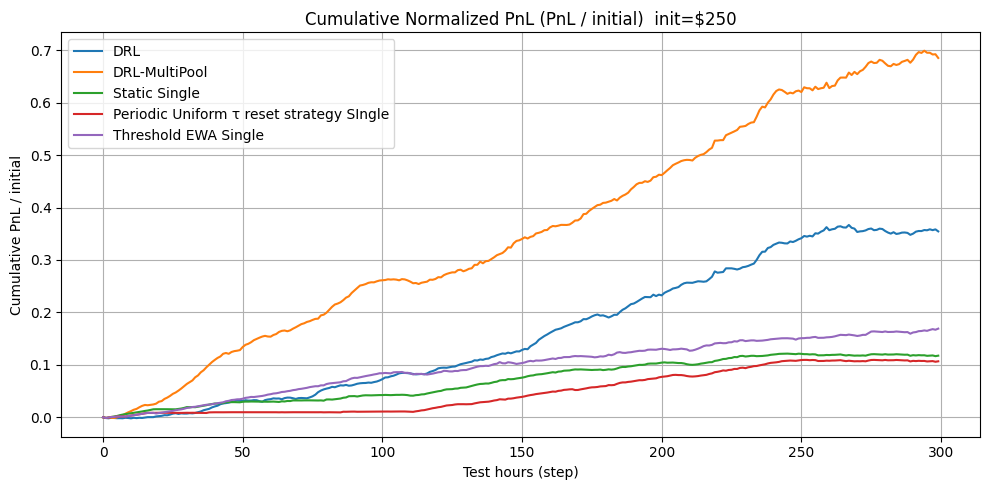

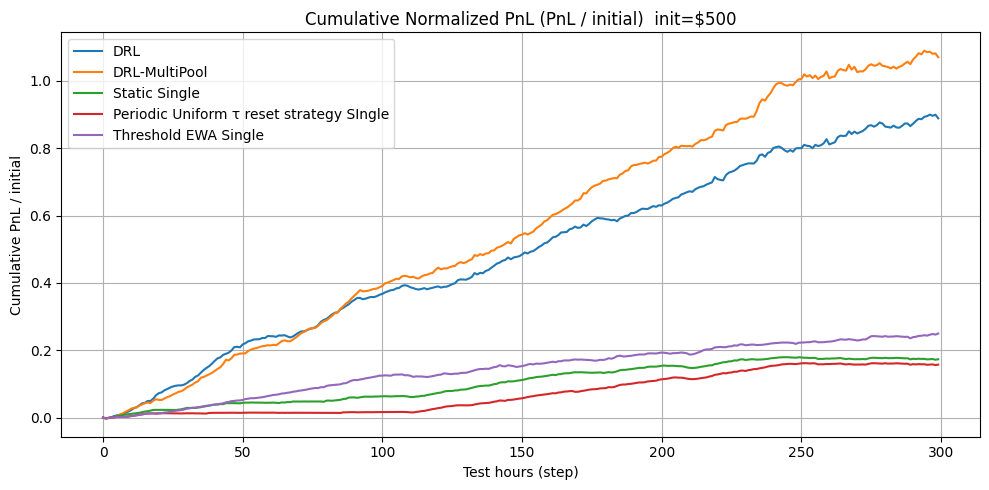

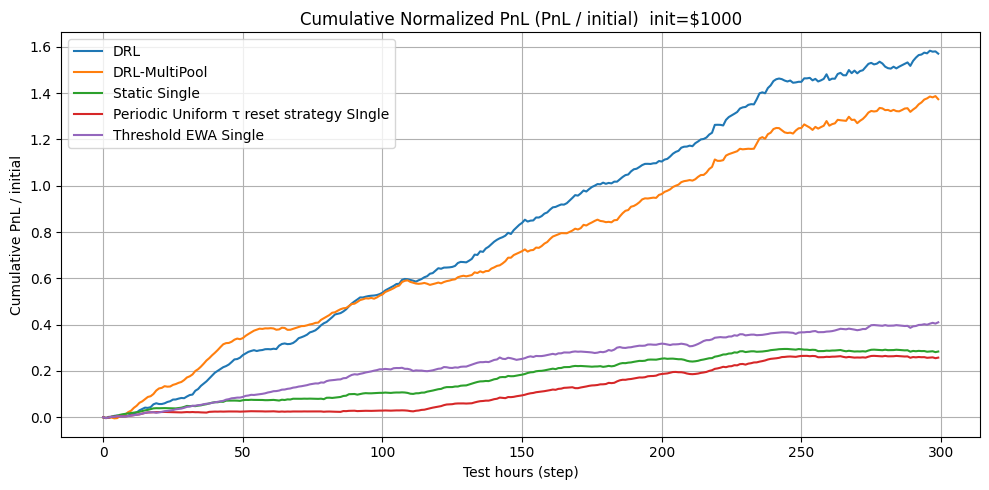

In [31]:

# Plotting
for init_cap in CONFIG['initial_capital_list']:
    plt.figure(figsize=(10,5))
    data = results_by_initial[init_cap]
    max_len = max(len(v) for v in data.values())
    for name, arr in data.items():
        if len(arr) < max_len:
            arr_plot = np.concatenate([arr, np.full(max_len - len(arr), arr[-1])])
        else:
            arr_plot = arr
        plt.plot(arr_plot, label=name)
    plt.title(f'Cumulative Normalized PnL (PnL / initial)  init=${init_cap:.0f}')
    plt.xlabel('Test hours (step)')
    plt.ylabel('Cumulative PnL / initial')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [32]:
#computing performance metrics for each model

def compute_metrics(model_name, pnl_series, rewards, il_history, init_cap):

    # ----- Cumulative Return -----
    cumulative_return = pnl_series[-1]  # already normalized by init_cap

    # ----- Impermanent Loss -----
    total_il = -np.sum(il_history)        # reward stored negative IL
    normalized_il = total_il / init_cap

    if init_cap == 1000:
      return {
        "Model": model_name,
        "Cumulative Return": cumulative_return,
        "Normalized IL": normalized_il
    }
    return {
        "Model": model_name,
        "Cumulative Return": cumulative_return,
        "Normalized IL": normalized_il
    }

In [33]:
# final metrics for each initial capital & each model
all_metrics = {}

for init_cap in CONFIG['initial_capital_list']:
    metrics = []

    for model_name, pnl_series in results_by_initial[init_cap].items():

        # Extract from stored evaluation environments:
        if model_name == "DRL":
            env = drl_res["env"]
            rewards = drl_res["rewards"]
        elif model_name == "DRL-MultiPool":
            env = drl_mp_res["env"]
            rewards = drl_mp_res["rewards"]
        # static / periodic / threshold:
        else:
            # These do not currently store env in your code.
            # You can modify evaluate_* to return env, or skip IL & Sharpe for now.
            continue

        # extract impermanent loss trace
        il_history = [h["components"]["il"] for h in env.history]

        metrics.append(
            compute_metrics(model_name, pnl_series, rewards, il_history, init_cap)
        )

    all_metrics[init_cap] = metrics


In [34]:
for init_cap, metric_list in all_metrics.items():
    print(f"\n=== Initial Capital = {init_cap} ===")
    for m in metric_list:
        print(m)



=== Initial Capital = 250.0 ===
{'Model': 'DRL', 'Cumulative Return': np.float64(0.3544958320721263), 'Normalized IL': np.float64(0.6140573209313772)}
{'Model': 'DRL-MultiPool', 'Cumulative Return': np.float64(0.6852349462750446), 'Normalized IL': np.float64(0.2525320561296319)}

=== Initial Capital = 500.0 ===
{'Model': 'DRL', 'Cumulative Return': np.float64(0.8886002090569859), 'Normalized IL': np.float64(0.3070286604656886)}
{'Model': 'DRL-MultiPool', 'Cumulative Return': np.float64(1.069877382231249), 'Normalized IL': np.float64(0.12626602806481596)}

=== Initial Capital = 1000.0 ===
{'Model': 'DRL', 'Cumulative Return': np.float64(1.5701226462222868), 'Normalized IL': np.float64(0.1535143302328443)}
{'Model': 'DRL-MultiPool', 'Cumulative Return': np.float64(1.373487909501409), 'Normalized IL': np.float64(0.06313301403240798)}


#Additional extension for the baseline models (MultiPool)

In [35]:
# Additional extension of static, periodic and threshold to MultiPool.

# Final evaluations, training wrappers, PnL recorder, plotting, main loop


#rebuild multi_pool_data and pool_dfs correctly if necessary

def _rebuild_data_if_needed():
    global multi_pool_data, pool_dfs, FEATURE_COLS

    try:
        # basic validation
        if not isinstance(multi_pool_data, dict) or len(multi_pool_data) == 0:
            raise Exception("rebuild")
        # check first item keys
        sample = next(iter(multi_pool_data.values()))
        if 'close' not in sample.columns:
            raise Exception("rebuild")
    except Exception:
        multi_pool_data = load_multi_pool_data(CONFIG['pools'], CONFIG['hours_total'])
        pool_dfs = {}
        FEATURE_COLS = None
        for p, df in multi_pool_data.items():
            df_f, fcols = create_features_for_df(df)
            pool_dfs[p] = df_f.reset_index(drop=True)
            FEATURE_COLS = fcols

# call patch
_rebuild_data_if_needed()



# baseline eval (multi-pool variants)


def evaluate_static_multi(env):
    env.reset(0)
    widest_idx = len(env.widths) - 1
    # deploy widest for each pool at t=0..n_pools-1
    for p_idx in range(env.n_pools):
        # action index mapping: 1 + pool_idx * n_width_nonzero + (width_index-1)
        action = 1 + p_idx * env.n_width_nonzero + (widest_idx - 1)
        env.step(action)
    rewards = []
    done = False
    while not done:
        _, reward, done, _ = env.step(0)
        rewards.append(reward)
    return {'name':'Static','pnl':env.get_total_pnl(),'rewards':np.array(rewards)}


def evaluate_periodic_multi(env, period=168):
    env.reset(0)
    rewards = []
    any_len = len(env.pool_dfs[env.pool_names[0]])
    for step in range(any_len-1):
        if step % period == 0:
            p_idx = (step // period) % env.n_pools
            mid_idx = max(1, env.n_width_nonzero // 2)
            action = 1 + p_idx * env.n_width_nonzero + (mid_idx - 1)
            _, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done: break
        else:
            _, reward, done, _ = env.step(0)
            rewards.append(reward)
            if done: break
    return {'name':'Periodic','pnl':env.get_total_pnl(),'rewards':np.array(rewards)}


def evaluate_threshold_multi(env, threshold=0.05):
    env.reset(0)
    # initial deploy median width for each pool
    mid_idx = max(1, env.n_width_nonzero // 2)
    for p_idx in range(env.n_pools):
        action = 1 + p_idx * env.n_width_nonzero + (mid_idx - 1)
        env.step(action)
    rewards = []
    last_prices = {p: env.pool_dfs[p].loc[env.step_idx, 'close'] for p in env.pool_names}
    done = False
    while not done:
        curr_prices = {p: env.pool_dfs[p].loc[env.step_idx, 'close'] for p in env.pool_names}
        rebalance_pool = None
        for p in env.pool_names:
            pct_move = abs(curr_prices[p] - last_prices[p]) / (last_prices[p] + 1e-8)
            if pct_move > threshold:
                rebalance_pool = p
                last_prices[p] = curr_prices[p]
                break
        if rebalance_pool is not None:
            p_idx = env.pool_names.index(rebalance_pool)
            action = 1 + p_idx * env.n_width_nonzero + (mid_idx - 1)
        else:
            action = 0
        _, reward, done, _ = env.step(action)
        rewards.append(reward)
    return {'name':f'Threshold_{int(threshold*100)}%','pnl':env.get_total_pnl(),'rewards':np.array(rewards)}



In [36]:
#  Training wrapper for single DRL (original; trains on multi-pool env but using same agent API)


def train_and_eval_for_initial(init_cap):
    train_end = CONFIG['train_hours']
    val_end = train_end + CONFIG['val_hours']
    test_end = val_end + CONFIG['test_hours']

    train_pool_dfs = {p: df.iloc[:train_end].reset_index(drop=True) for p, df in pool_dfs.items()}
    test_pool_dfs  = {p: df.iloc[val_end:test_end].reset_index(drop=True) for p, df in pool_dfs.items()}

    train_env = UniswapMultiPoolEnv(train_pool_dfs, FEATURE_COLS, CONFIG, init_cap)
    test_env  = UniswapMultiPoolEnv(test_pool_dfs,  FEATURE_COLS, CONFIG, init_cap)

    agent = DRLAgent(train_env.n_features, train_env.n_actions, CONFIG)

    # Train
    n_episodes = 20
    episode_length = 300
    for ep in range(n_episodes):
        start_idx = random.randint(0, max(1, CONFIG['train_hours'] - episode_length - 1))
        state = train_env.reset(start_idx)
        for t in range(episode_length):
            a = agent.select_action(state, training=True)
            ns, r, d, _ = train_env.step(a)
            agent.remember(state, a, r, ns, d)
            _ = agent.learn()
            state = ns
            if d: break

    #Test evaluation
    state = test_env.reset(0)
    drl_rewards = []; drl_actions = []
    while True:
        a = agent.select_action(state, training=False)
        ns, r, d, _ = test_env.step(a)
        drl_rewards.append(r); drl_actions.append(a); state = ns
        if d: break

    drl_res = {'name':'DRL','pnl':test_env.get_total_pnl(),'rewards':np.array(drl_rewards),'actions':np.array(drl_actions),'env':test_env}

    # Baselines run on fresh test env copies
    static = evaluate_static_multi(test_env)
    periodic = evaluate_periodic_multi(test_env)
    threshold = evaluate_threshold_multi(test_env, threshold=0.05)

    return drl_res, static, periodic, threshold


#  Training wrapper for Multi-Pool DRL agent (DRL-MP)



def train_and_eval_multi_agent(init_cap):
    train_end = CONFIG['train_hours']
    val_end = train_end + CONFIG['val_hours']
    test_end = val_end + CONFIG['test_hours']

    train_pool_dfs = {p: df.iloc[:train_end].reset_index(drop=True) for p, df in pool_dfs.items()}
    test_pool_dfs  = {p: df.iloc[val_end:test_end].reset_index(drop=True) for p, df in pool_dfs.items()}

    train_env = UniswapMultiPoolEnv(train_pool_dfs, FEATURE_COLS, CONFIG, init_cap)
    test_env  = UniswapMultiPoolEnv(test_pool_dfs,  FEATURE_COLS, CONFIG, init_cap)

    agent = DRLAgent(train_env.n_features, train_env.n_actions, CONFIG)

    # Training
    n_episodes = 50
    episode_length = 400
    for ep in range(n_episodes):
        start_idx = random.randint(0, max(1, CONFIG['train_hours'] - episode_length - 1))
        state = train_env.reset(start_idx)
        for t in range(episode_length):
            a = agent.select_action(state, training=True)
            ns, r, d, _ = train_env.step(a)
            agent.remember(state, a, r, ns, d)
            _ = agent.learn()
            state = ns
            if d: break
#test
    state = test_env.reset(0)
    rewards = []; actions = []
    while True:
        a = agent.select_action(state, training=False)
        ns, r, d, _ = test_env.step(a)
        rewards.append(r); actions.append(a); state = ns
        if d: break

    return {'name':'DRL-MP', 'pnl':test_env.get_total_pnl(), 'rewards':np.array(rewards), 'actions':np.array(actions), 'env':test_env}





In [37]:

# we are recording PnL sequence for each method on a fresh test environment


def record_pnl_sequence(method_name, init_cap, drl_res=None, drl_mp_res=None):
    test_pool_dfs = {p: pool_dfs[p].iloc[CONFIG['train_hours']+CONFIG['val_hours']:CONFIG['train_hours']+CONFIG['val_hours']+CONFIG['test_hours']].reset_index(drop=True) for p in pool_dfs}
    env = UniswapMultiPoolEnv(test_pool_dfs, FEATURE_COLS, CONFIG, init_cap)
    _ = env.reset(0)
    pnls = [0.0]  # initial 0 pnl

    if method_name == 'drl':
        actions_seq = drl_res['actions']
        step = 0
        while True:
            a = int(actions_seq[step]) if step < len(actions_seq) else 0
            ns, r, d, _ = env.step(a)
            pnls.append(env.get_total_pnl()); step += 1
            if d: break

    elif method_name == 'drl_mp':
        actions_seq = drl_mp_res['actions']
        step = 0
        while True:
            a = int(actions_seq[step]) if step < len(actions_seq) else 0
            ns, r, d, _ = env.step(a)
            pnls.append(env.get_total_pnl()); step += 1
            if d: break

    elif method_name == 'static':
        widest_idx = len(env.widths) - 1
        for p_idx in range(env.n_pools):
            a = 1 + p_idx * env.n_width_nonzero + (widest_idx - 1)
            env.step(a)
            pnls.append(env.get_total_pnl())
        done = False
        while not done:
            _, r, done, _ = env.step(0); pnls.append(env.get_total_pnl())

    elif method_name == 'periodic':
        period = 168
        step = 0
        while True:
            if step % period == 0:
                p_idx = (step // period) % env.n_pools
                mid_idx = max(1, env.n_width_nonzero // 2)
                a = 1 + p_idx * env.n_width_nonzero + (mid_idx - 1)
            else:
                a = 0
            ns, r, d, _ = env.step(a)
            pnls.append(env.get_total_pnl()); step += 1
            if d: break

    elif method_name == 'threshold':
        mid_idx = max(1, env.n_width_nonzero // 2)
        for p_idx in range(env.n_pools):
            a = 1 + p_idx * env.n_width_nonzero + (mid_idx - 1)
            env.step(a)
            pnls.append(env.get_total_pnl())
        last_prices = {p: env.pool_dfs[p].loc[env.step_idx, 'close'] for p in env.pool_names}
        done = False
        while not done:
            curr_prices = {p: env.pool_dfs[p].loc[env.step_idx, 'close'] for p in env.pool_names}
            rebalance_pool = None
            for p in env.pool_names:
                pct_move = abs(curr_prices[p] - last_prices[p]) / (last_prices[p] + 1e-8)
                if pct_move > 0.05:
                    rebalance_pool = p; last_prices[p] = curr_prices[p]; break
            if rebalance_pool is not None:
                p_idx = env.pool_names.index(rebalance_pool)
                a = 1 + p_idx * env.n_width_nonzero + (mid_idx - 1)
            else:
                a = 0
            ns, r, d, _ = env.step(a)
            pnls.append(env.get_total_pnl())
            if d: break

    return np.array(pnls)


In [38]:

# run for each initial capital, train & evaluate all 5 models, plot

results_by_initial = {}
i=0
for init_cap in CONFIG['initial_capital_list']:
    print('Running initial capital =', init_cap)

    # train main DRL (original)
    drl_res, static_res, periodic_res, threshold_res = train_and_eval_for_initial(init_cap)

    # train DRL multi-pool agent (new)
    drl_mp_res = train_and_eval_multi_agent(init_cap)

    # record PnL sequences
    drl_pnls = record_pnl_sequence('drl', init_cap, drl_res=drl_res)
    drl_mp_pnls = record_pnl_sequence('drl_mp', init_cap, drl_mp_res=drl_mp_res)
    static_pnls = record_pnl_sequence('static', init_cap)
    periodic_pnls = record_pnl_sequence('periodic', init_cap)
    threshold_pnls = record_pnl_sequence('threshold', init_cap)

    # normalize by initial capital
    results_by_initial[init_cap] = {
        'DRL': drl_pnls / init_capital[i],
        'DRL-MultiPool': drl_mp_pnls / init_capital[i],
        'Static': static_pnls / init_capital[i],
        'Periodic Uniform τ reset strategy': periodic_pnls / init_capital[i],
        'Threshold EWA': threshold_pnls / init_capital[i]


    }
    i+=1


Running initial capital = 250.0
Running initial capital = 500.0
Running initial capital = 1000.0


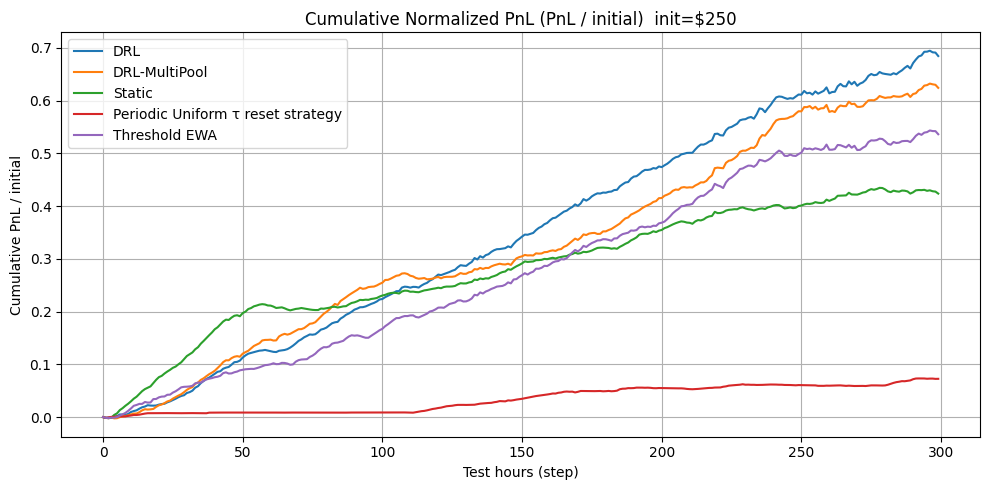

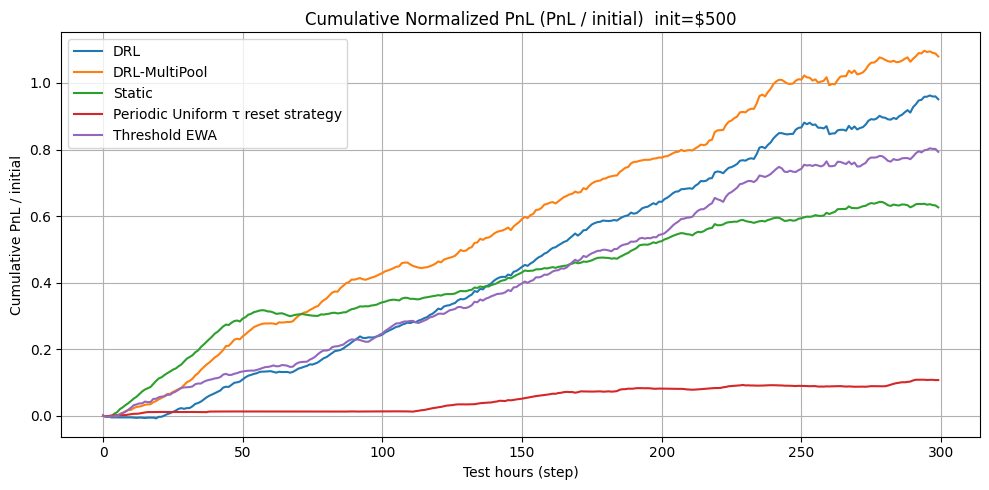

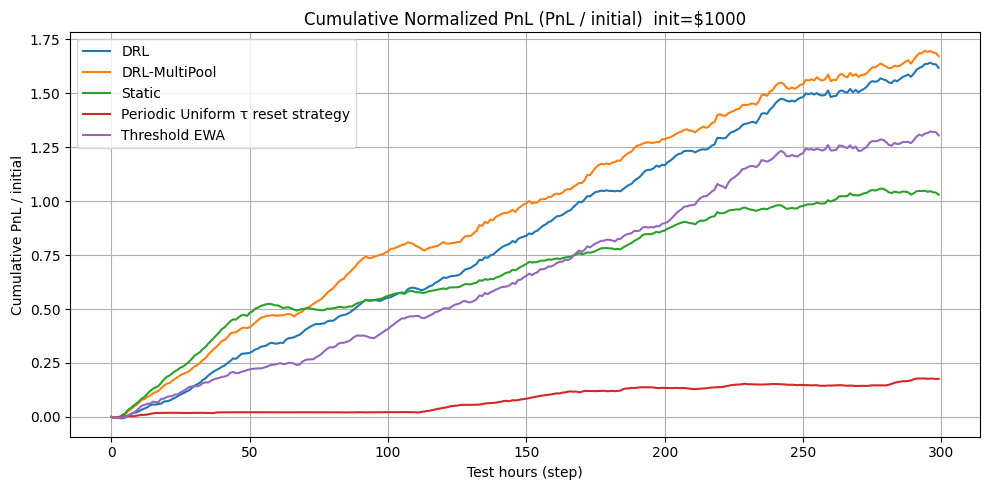

In [39]:

# Plotting
for init_cap in CONFIG['initial_capital_list']:
    plt.figure(figsize=(10,5))
    data = results_by_initial[init_cap]
    max_len = max(len(v) for v in data.values())
    for name, arr in data.items():
        if len(arr) < max_len:
            arr_plot = np.concatenate([arr, np.full(max_len - len(arr), arr[-1])])
        else:
            arr_plot = arr
        plt.plot(arr_plot, label=name)
    plt.title(f'Cumulative Normalized PnL (PnL / initial)  init=${init_cap:.0f}')
    plt.xlabel('Test hours (step)')
    plt.ylabel('Cumulative PnL / initial')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()